In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
#Loading the dataset
diabetes_data = pd.read_csv('diabetes.csv')

#Print the first 5 rows of the dataframe.
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
## observing the shape of the data
diabetes_data.shape

(768, 9)

In [4]:
X = diabetes_data.drop("Outcome",axis = 1)
y = diabetes_data.Outcome

In [5]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [6]:
#importing train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=1/3,random_state=42, stratify=y)

# Decision Tree

In [7]:
from sklearn.tree import DecisionTreeClassifier
# Step 1: Train the model
# entropy: information gain
# default criterion is gini -- gini impurity
dt = DecisionTreeClassifier(criterion='entropy',random_state=0) #entropy function used to determine quality of split; random state ensures reproducible results i.e. same tree structure every time
dt.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(dt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(dt.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.703


The accuracy on the training set is 100%, while the test set accuracy is much worse. This is an indicative that the tree is overfitting and not generalizing well to new data. Therefore, we need to apply pre-pruning to the tree.

We set max_depth=3, limiting the depth of the tree decreases overfitting. This leads to a lower accuracy on the training set, but an improvement on the test set.

In [8]:
# max_depth limits depth of tree to prevent overfitting; helps tune model complexity
# •	Smaller max_depth: lower variance, may underfit.
# •	Larger max_depth: higher variance, may overfit.
dt = DecisionTreeClassifier(criterion='entropy',max_depth=3, random_state=0)
dt.fit(X_train, y_train)
print("Accuracy on training set: {:.3f}".format(dt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(dt.score(X_test, y_test)))

Accuracy on training set: 0.793
Accuracy on test set: 0.730


In [9]:
y_pred = dt.predict(X_test)


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[145  22]
 [ 47  42]]
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       167
           1       0.66      0.47      0.55        89

    accuracy                           0.73       256
   macro avg       0.71      0.67      0.68       256
weighted avg       0.72      0.73      0.72       256



In [ ]:
import pydotplus

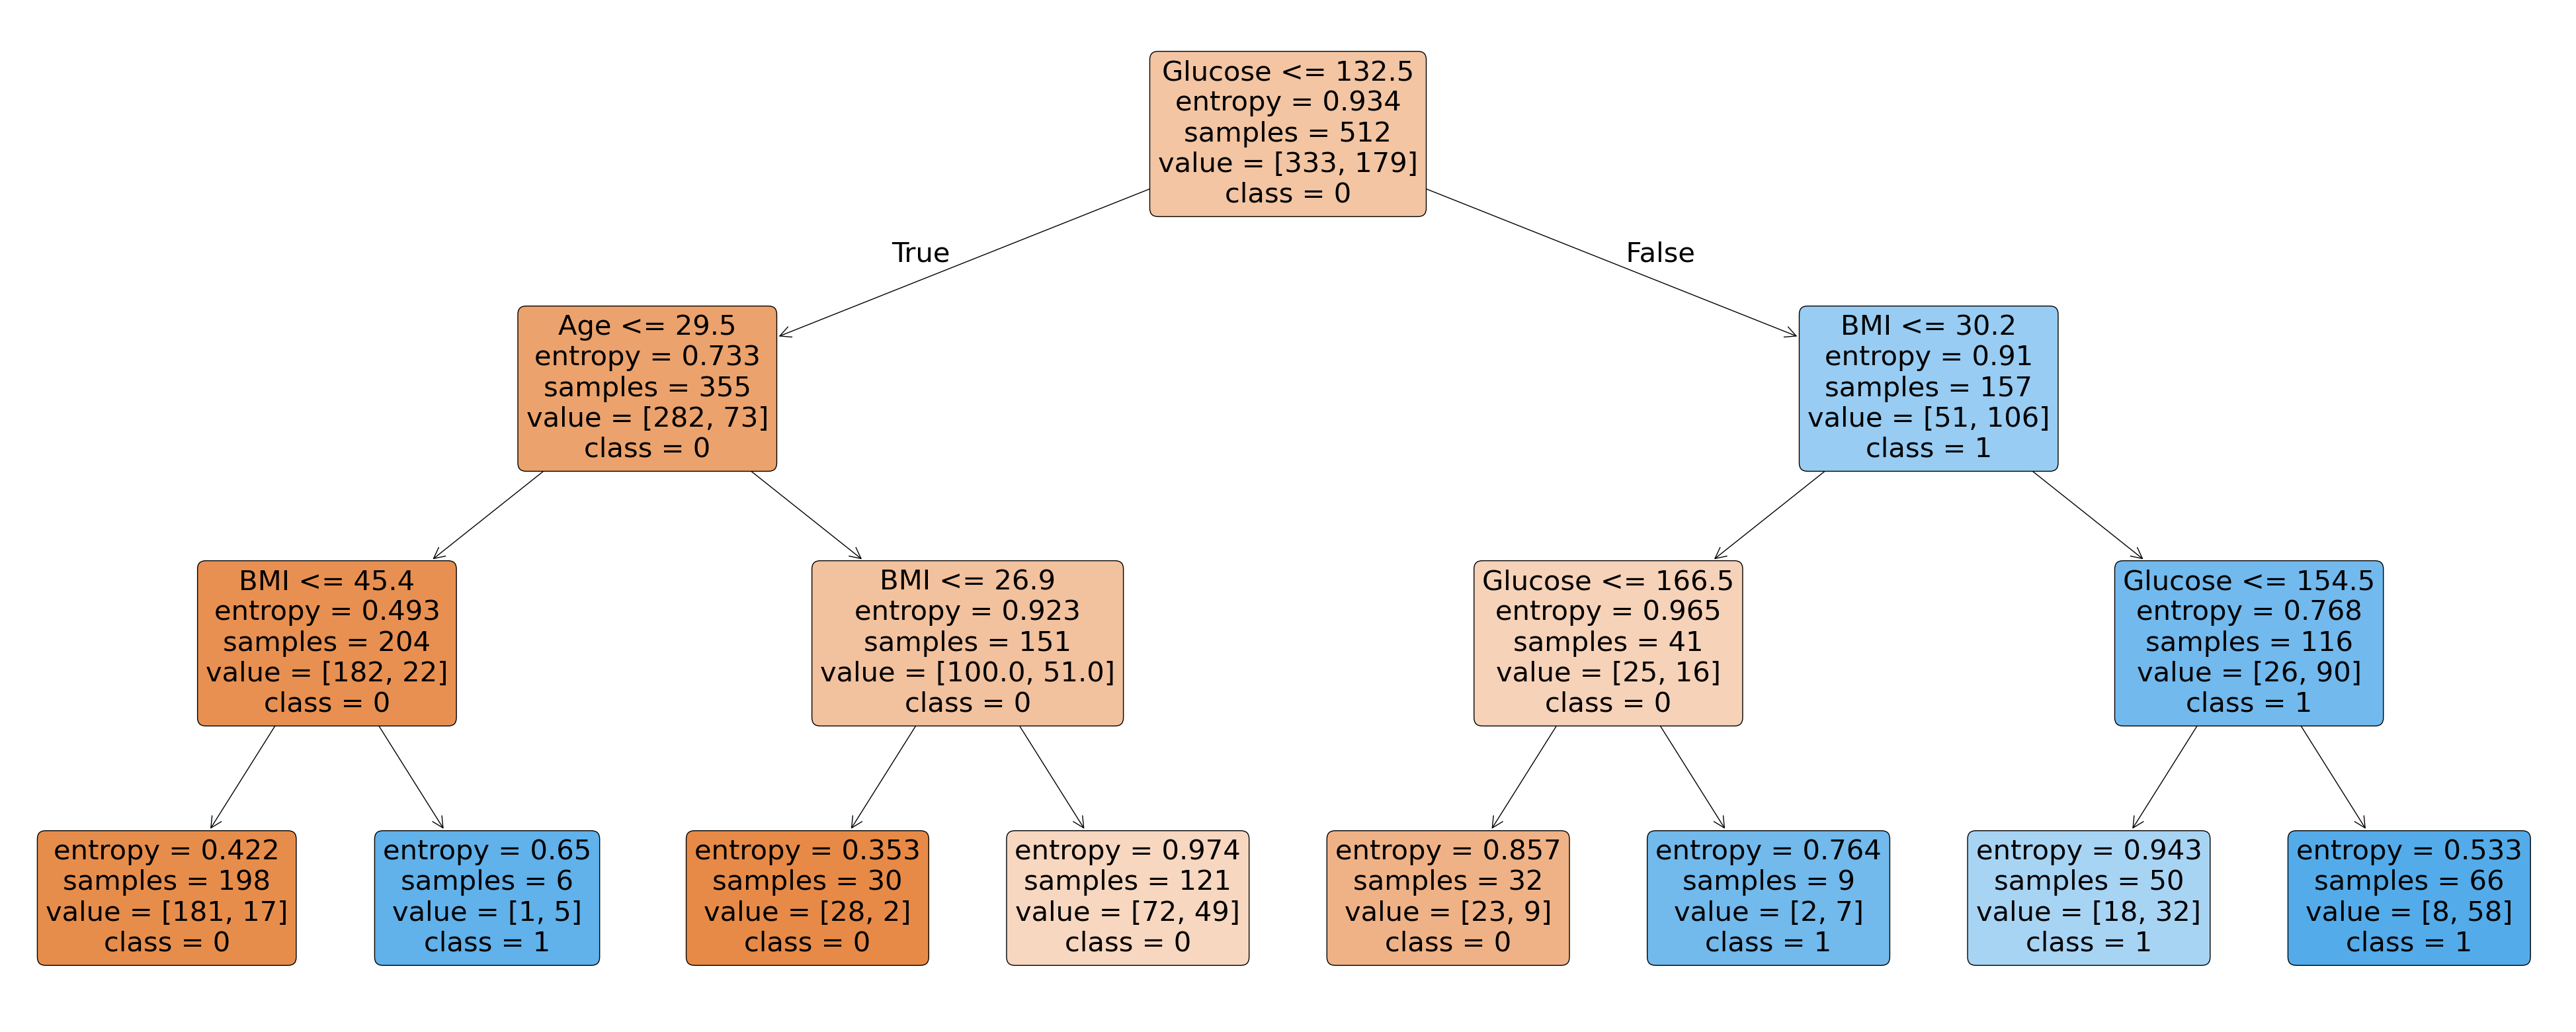

In [12]:
from sklearn import tree

#import matplotlib.pyplot as plt
plt.figure(figsize=[50,20])

feature_names=X.columns.tolist()
tree.plot_tree(dt,filled=True,fontsize=30,rounded=True,feature_names=feature_names,class_names=['0','1'])
plt.show()

In [ ]:
#Plot ROC chart for DT. Write your code below.

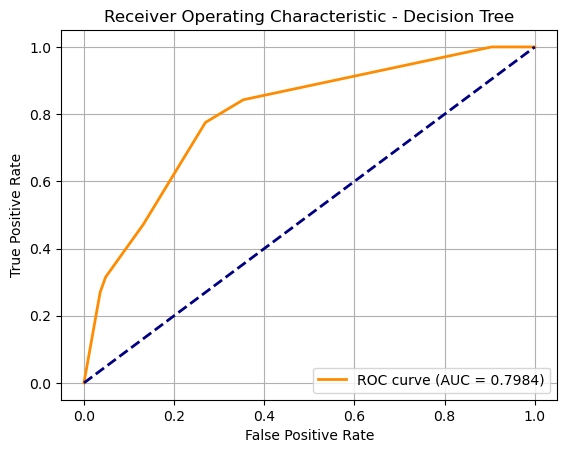

In [16]:
from sklearn.metrics import roc_curve, auc
#Get predicted probabilities (as opposed to class labels)
y_probs = dt.predict_proba(X_test)[:, 1]  # returns probabilities for both classes; we select the positive class

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs) #y_test values should be binary
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Decision Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Adjust the decision tree parameters to improve the performance.Write your code below.

In [54]:
# min_samples_split - prevent small split by setting Minimum samples required to split a node
dt1 = DecisionTreeClassifier(criterion='entropy',max_depth=10,min_samples_split=24,random_state=0)
dt1.fit(X_train, y_train)
print("Accuracy on training set: {:.4f}".format(dt1.score(X_train, y_train)))
print("Accuracy on test set: {:.4f}".format(dt1.score(X_test, y_test)))

#CONCLUSION: IF MAX DEPTH=3, same till 40; 50 reduces further ==> NOT HELPFUL HERE
#CONCLUSION: IF MAX DEPTH=10, increase till 24; then reduces ==> HELPFUL HERE

Accuracy on training set: 0.8652
Accuracy on test set: 0.7578


In [65]:
# min_samples_leaf - prevent less sample leaves by setting MINIMUM samples required to be at a leaf node
dt1 = DecisionTreeClassifier(criterion='entropy',max_depth=10,min_samples_leaf=20,random_state=0)
dt1.fit(X_train, y_train)
print("Accuracy on training set: {:.4f}".format(dt1.score(X_train, y_train)))
print("Accuracy on test set: {:.4f}".format(dt1.score(X_test, y_test)))

#CONCLUSION: IF MAX DEPTH=3, same till 15; 20 reduces further ==> NOT HELPFUL HERE
#CONCLUSION: IF MAX DEPTH=10, peaks at 20 ==> HELPFUL HERE

Accuracy on training set: 0.7988
Accuracy on test set: 0.7617


In [111]:
# max_features - prevent overfitting by setting MAX Number of features to consider when looking for the best split
dt1 = DecisionTreeClassifier(criterion='entropy',max_depth=10,min_samples_split=24,max_features=5,random_state=0)
dt1.fit(X_train, y_train)
print("Accuracy on training set: {:.4f}".format(dt1.score(X_train, y_train)))
print("Accuracy on test set: {:.4f}".format(dt1.score(X_test, y_test)))

#CONCLUSION: IF MAX DEPTH=10,min_samples_split=24 THEN peaks at max_features=5 ==> HELPFUL HERE
# max_features='sqrt' or 'log2' ==> NOT HELPFUL HERE

Accuracy on training set: 0.8516
Accuracy on test set: 0.7734


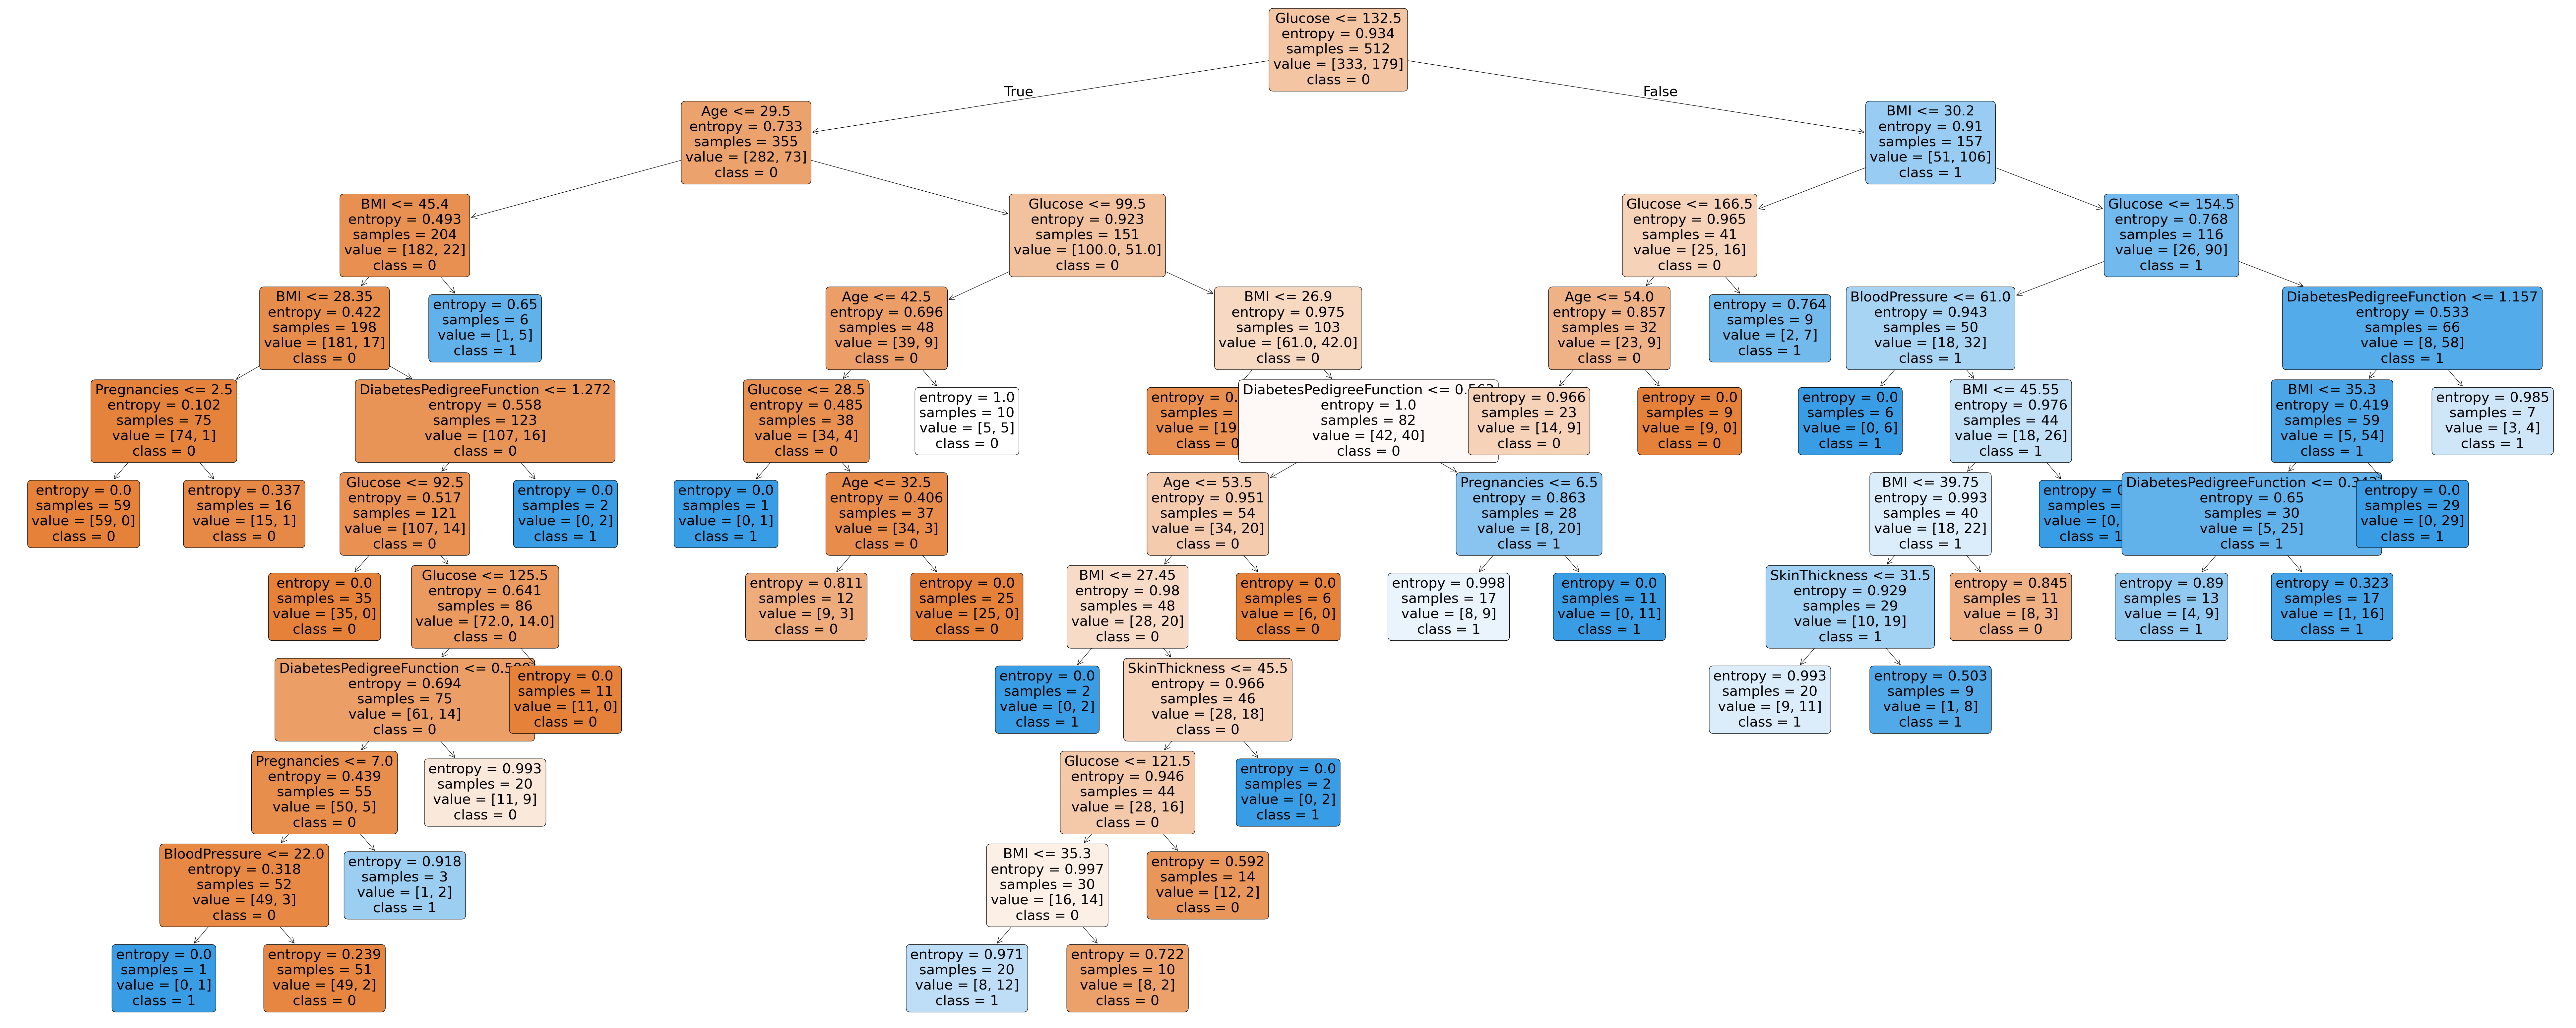

In [113]:
plt.figure(figsize=[100,40])
feature_names=X.columns.tolist()
tree.plot_tree(dt1,filled=True,fontsize=30,rounded=True,feature_names=feature_names,class_names=['0','1'])
plt.show()

In [108]:
# max_leaf_nodes - helps generalisation by setting FIXED/MAX number of leaves; prunes the tree
dt1 = DecisionTreeClassifier(criterion='entropy',max_depth=10,min_samples_split=24,max_leaf_nodes=9,random_state=0)
dt1.fit(X_train, y_train)
print("Accuracy on training set: {:.4f}".format(dt1.score(X_train, y_train)))
print("Accuracy on test set: {:.4f}".format(dt1.score(X_test, y_test)))

#CONCLUSION: peaks at max_leaf_nodes=5 ==> NOT HELPFUL HERE sice this already achieved with max_depth=10,min_samples_split=24

Accuracy on training set: 0.8047
Accuracy on test set: 0.7578


In [159]:
# class_weight - helps balance classes by adjusting weights for unbalanced classes
dt1 = DecisionTreeClassifier(criterion='entropy',max_depth=11,min_samples_split=16,max_features=7,class_weight='balanced',random_state=0)
dt1.fit(X_train, y_train)
print("Accuracy on training set: {:.4f}".format(dt1.score(X_train, y_train)))
print("Accuracy on test set: {:.4f}".format(dt1.score(X_test, y_test)))

#CONCLUSION: HELPFUL HERE if we allow deepr trees with more features and lesser constraints on splits

Accuracy on training set: 0.8770
Accuracy on test set: 0.7734


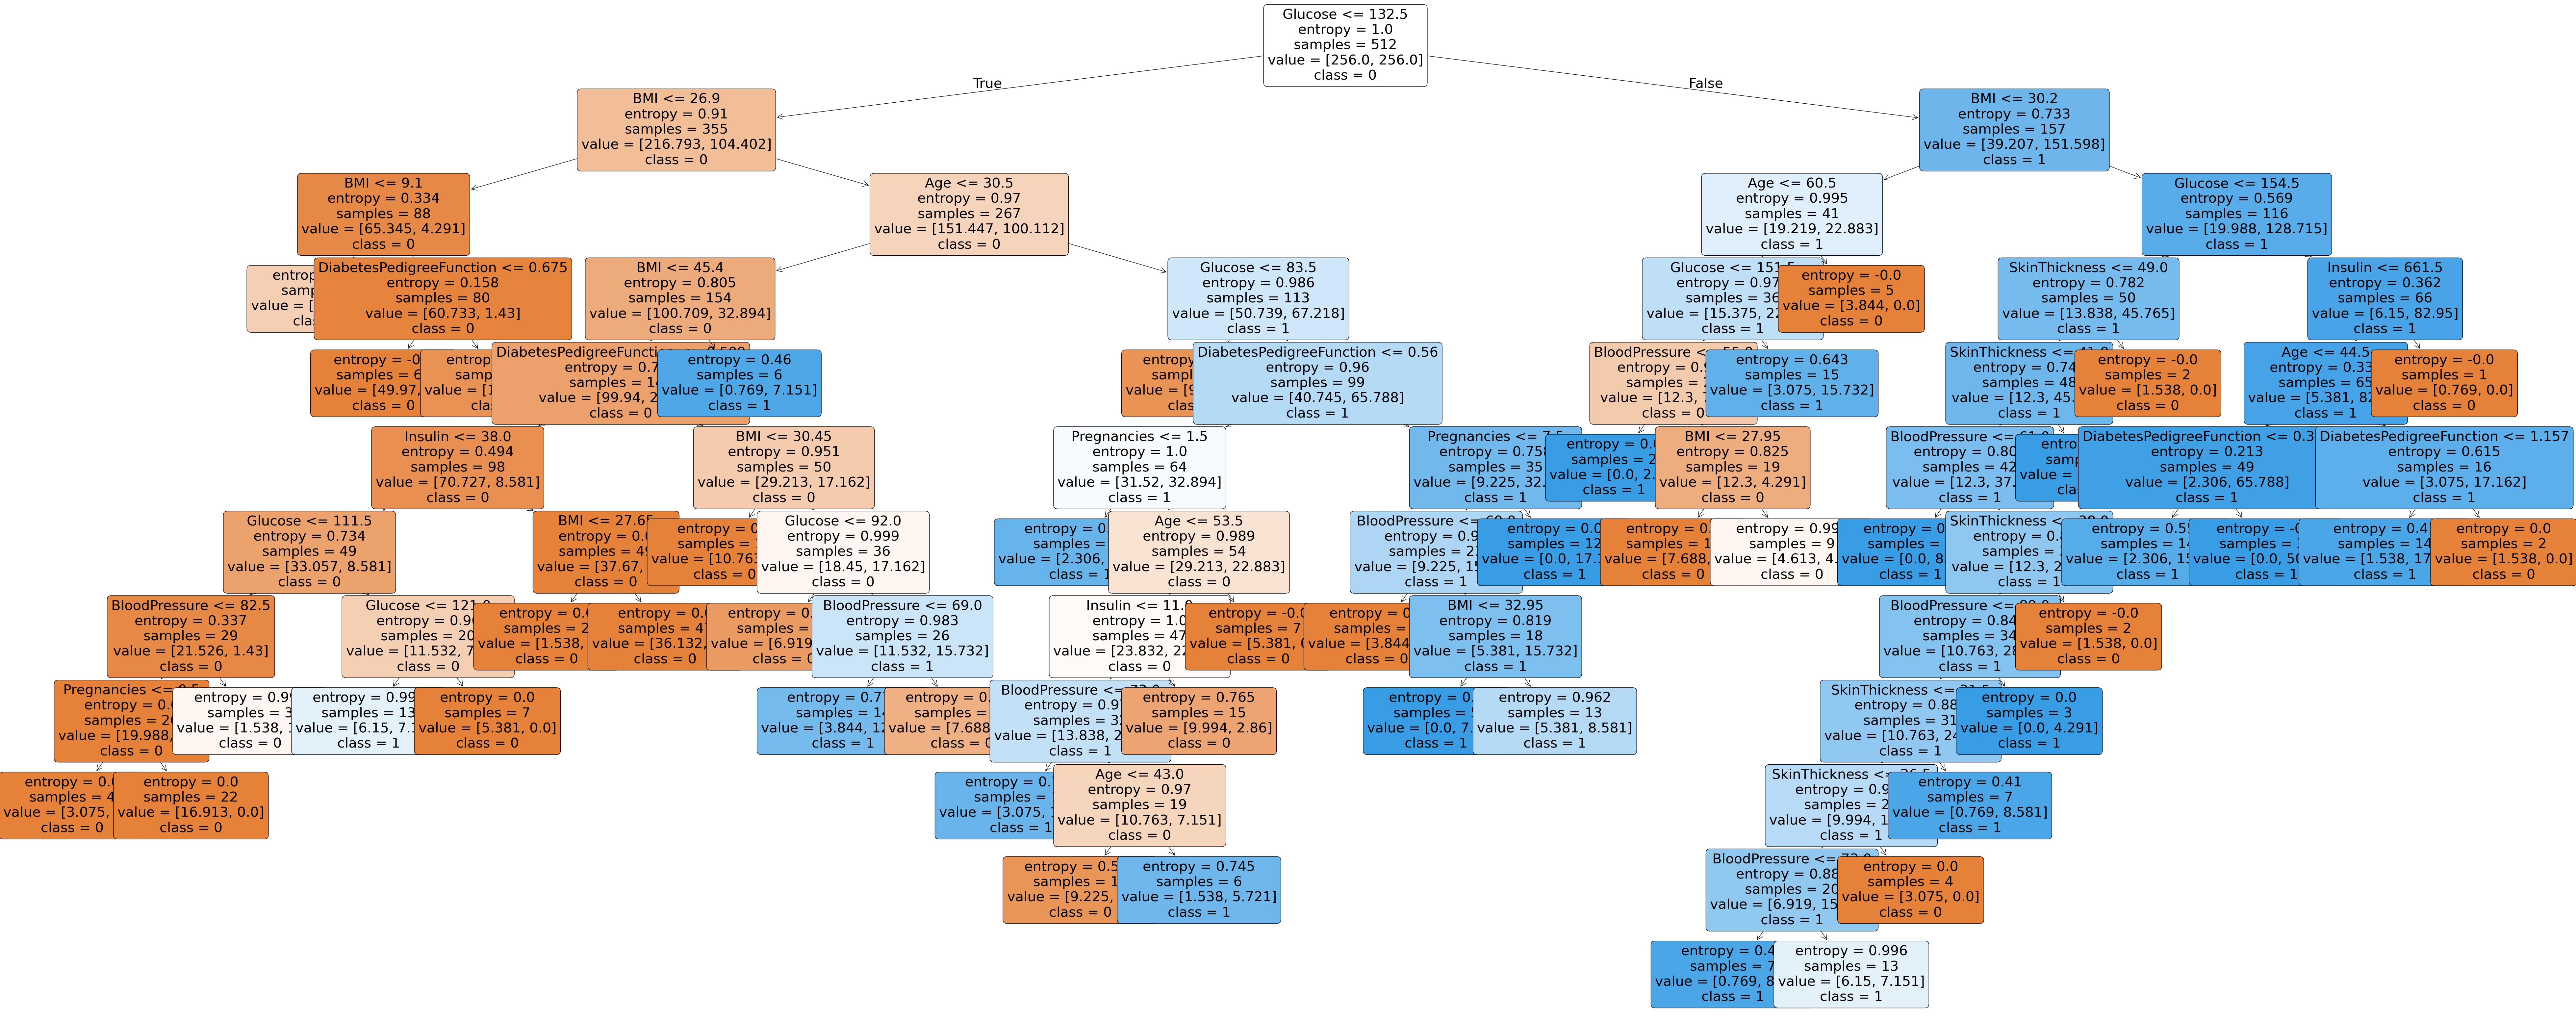

In [150]:
plt.figure(figsize=[100,40])
feature_names=X.columns.tolist()
tree.plot_tree(dt1,filled=True,fontsize=30,rounded=True,feature_names=feature_names,class_names=['0','1'])
plt.show()

In [162]:
# Implement Cross-Validation with GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define parameter grid to search
param_grid = {
    'criterion': ['entropy','gini'],
    'max_depth': [3, 5, 8, 10, 11, 12, 15],
    'min_samples_split': [8, 13, 16, 19, 24, 25, 30],
    'min_samples_leaf': [1, 5, 10, 15, 20],
    'max_features': [4, 5, 6, 7, 8],
    'class_weight': [None, 'balanced']
}

# Initialize model
dt2 = DecisionTreeClassifier(random_state=0)

# Set up GridSearchCV with 5-fold cross-validation
# grid_search = GridSearchCV(dt2, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search = GridSearchCV(dt2, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1) # for data is imbalanced, accuracy may be misleading

# Fit model
grid_search.fit(X_train, y_train)

# Best estimator and score
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
# print("Accuracy on training set: {:.4f}".format(dt1.score(X_train, y_train)))
# print("Accuracy on test set: {:.4f}".format(dt1.score(X_test, y_test)))

#results with accuracy:
# Best Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 8, 'min_samples_leaf': 1, 'min_samples_split': 13}
# Best CV Score: 0.7793641728536075
# Test Accuracy: 0.71875

#ROC is clearly better

Fitting 5 folds for each of 4900 candidates, totalling 24500 fits
Best Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_features': 6, 'min_samples_leaf': 1, 'min_samples_split': 8}
Best CV Score: 0.8108306591142412
Test Accuracy: 0.74609375


In [168]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
# Define parameter grid to search
param_dist = {
    'criterion': ['entropy', 'gini'],
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 30),
    'min_samples_leaf': randint(1, 20),
    'max_features': randint(4, X_train.shape[1]),
    'class_weight': [None, 'balanced']
}

#Initialise
rand_search = RandomizedSearchCV(dt2, param_distributions=param_dist,
                                 n_iter=24500, cv=5, scoring='roc_auc',
                                 n_jobs=-1, random_state=0, verbose=1)
#fit
rand_search.fit(X_train, y_train)

# Best estimator and score
print("Best Parameters:", rand_search.best_params_)
print("Best CV Score:", rand_search.best_score_)

# Evaluate on test set
best_model = rand_search.best_estimator_
y_pred = best_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

#with accuracy and n_iter=100 totally 500 fits:
# Best Parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'max_features': 5, 'min_samples_leaf': 18, 'min_samples_split': 26}
# Best CV Score: 0.757852655625357
# Test Accuracy: 0.7578125

Fitting 5 folds for each of 24500 candidates, totalling 122500 fits
Best Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_features': 6, 'min_samples_leaf': 2, 'min_samples_split': 28}
Best CV Score: 0.8108306591142412
Test Accuracy: 0.74609375


In [ ]:
#future todo:
# RandomForestClassifier: handles variance better.
# XGBoost or GradientBoostingClassifier: better performance and robustness

#### conclusion: manual tuning can outperform GridSearchCV in many cases, especially when you understand the data better than a blind search

### find out the feature importance from the decision tree built above. Write your code below.


                    Feature  Importance
1                   Glucose    0.392290
5                       BMI    0.194334
7                       Age    0.103138
6  DiabetesPedigreeFunction    0.092795
2             BloodPressure    0.082165
0               Pregnancies    0.064763
3             SkinThickness    0.040383
4                   Insulin    0.030131


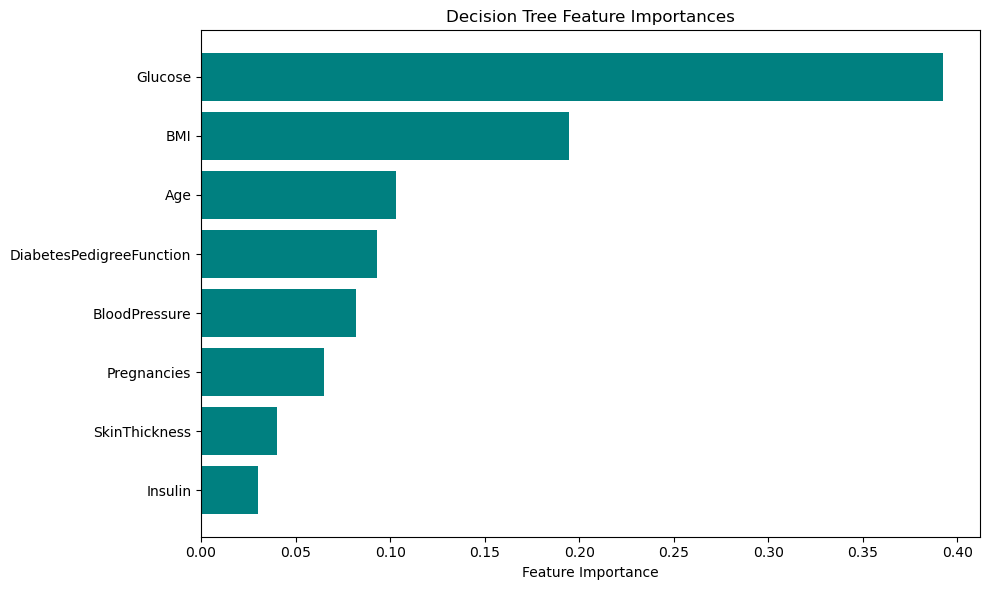

In [173]:
# Get feature importances
# higher value = more impact on decision
# all values normalised so sum=1
importances = dt1.feature_importances_

# If you have feature names (recommended):
feature_names = X_train.columns  # if X_train is a DataFrame

# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print top features
print(importance_df)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.xlabel('Feature Importance')
plt.title('Decision Tree Feature Importances')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.show()

In [183]:
#permutation importance is model agnostic and more reliable
#measures a feature’s importance by observing the change in model performance after randomly shuffling the values of that feature.
# Intuition: If shuffling a feature significantly worsens the model’s accuracy, the model relied heavily on that feature for predictions. If shuffling has little to no impact, the feature wasn’t very important.
# model agnostic because works with any model
from sklearn.inspection import permutation_importance

result = permutation_importance(dt1, X_test, y_test, n_repeats=10, random_state=0)
perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_df)

                    Feature  Importance
1                   Glucose    0.117969
5                       BMI    0.079687
7                       Age    0.061328
0               Pregnancies    0.019141
2             BloodPressure    0.013281
3             SkinThickness   -0.005859
4                   Insulin   -0.007812
6  DiabetesPedigreeFunction   -0.012891


#### Let's dive into insulin
Insulin is medically a critical predictor of diabeter but here it's ranking lowest - not same as the domain intuition
- Maybe it is because Insulin column has poor variability and lots of zeroes:
- Maybe other correlated features (like glucose, BMI, etc.) already capture the effect of insulin so it adds no new info

In [178]:
print(diabetes_data['Insulin'].describe())
diabetes_data['Insulin'].value_counts() #as can be seen, data is badly distributed, lopsided to 0

count    768.000000
mean      79.799479
std      115.244002
min        0.000000
25%        0.000000
50%       30.500000
75%      127.250000
max      846.000000
Name: Insulin, dtype: float64


Insulin
0      374
105     11
130      9
140      9
120      8
      ... 
178      1
127      1
510      1
16       1
112      1
Name: count, Length: 186, dtype: int64

In [182]:
diabetes_data.corr()['Insulin'].sort_values(ascending=False)

Insulin                     1.000000
SkinThickness               0.436783
Glucose                     0.331357
BMI                         0.197859
DiabetesPedigreeFunction    0.185071
Outcome                     0.130548
BloodPressure               0.088933
Age                        -0.042163
Pregnancies                -0.073535
Name: Insulin, dtype: float64

# NN

In [184]:

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [185]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=1000,verbose=2)
mlp.fit(X_train, y_train)

Iteration 1, loss = 0.74291465
Iteration 2, loss = 0.73539108
Iteration 3, loss = 0.72797154
Iteration 4, loss = 0.72135290
Iteration 5, loss = 0.71485925
Iteration 6, loss = 0.70881085
Iteration 7, loss = 0.70272416
Iteration 8, loss = 0.69729539
Iteration 9, loss = 0.69169826
Iteration 10, loss = 0.68641959
Iteration 11, loss = 0.68123653
Iteration 12, loss = 0.67652002
Iteration 13, loss = 0.67158795
Iteration 14, loss = 0.66714742
Iteration 15, loss = 0.66255601
Iteration 16, loss = 0.65839058
Iteration 17, loss = 0.65438046
Iteration 18, loss = 0.65026561
Iteration 19, loss = 0.64620827
Iteration 20, loss = 0.64250669
Iteration 21, loss = 0.63881601
Iteration 22, loss = 0.63521728
Iteration 23, loss = 0.63175683
Iteration 24, loss = 0.62807249
Iteration 25, loss = 0.62461117
Iteration 26, loss = 0.62117928
Iteration 27, loss = 0.61748892
Iteration 28, loss = 0.61413085
Iteration 29, loss = 0.61069244
Iteration 30, loss = 0.60734269
Iteration 31, loss = 0.60371242
Iteration 32, los

,hidden_layer_sizes,"(10, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,None


In [186]:
predictions = mlp.predict(X_test)


print("Accuracy", metrics.accuracy_score(y_test, predictions))
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

Accuracy 0.74609375
[[138  29]
 [ 36  53]]
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       167
           1       0.65      0.60      0.62        89

    accuracy                           0.75       256
   macro avg       0.72      0.71      0.71       256
weighted avg       0.74      0.75      0.74       256



In [188]:
print("Accuracy on training set: {:.4f}".format(mlp.score(X_train, y_train)))
print("Accuracy on test set: {:.4f}".format(mlp.score(X_test, y_test)))

Accuracy on training set: 0.8887
Accuracy on test set: 0.7461


In [189]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
import pandas as pd
import numpy as np

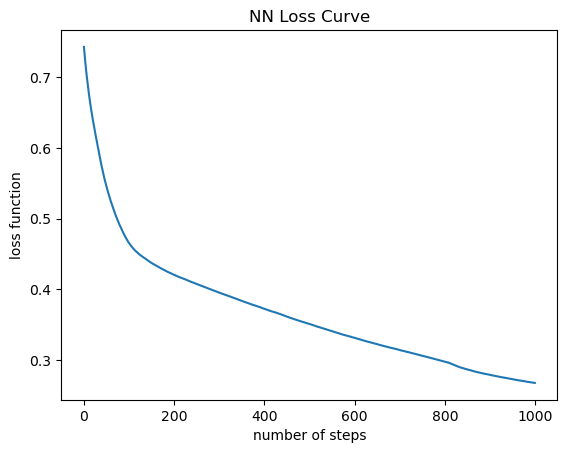

In [190]:
plt.plot(mlp.loss_curve_)
plt.title("NN Loss Curve")
plt.xlabel("number of steps")
plt.ylabel("loss function")
plt.show()

In [ ]:
#check out weights

In [191]:
(mlp.intercepts_[0]).shape

(10,)

In [192]:
(mlp.coefs_[0]).shape

(8, 10)

In [20]:
mlp.intercepts_[0]

array([ 0.45079054,  0.30052141, -1.22757998,  0.01087   ,  0.63989958,
        0.12000113, -0.52106044,  0.80612308,  0.60948684, -0.02596015])

In [21]:
mlp.coefs_[0]

array([[-3.75380729e-01,  8.53018042e-01, -5.08042603e-01,
        -7.46274894e-01, -3.66126044e-01,  1.96921152e-01,
        -1.10631146e+00,  7.30336843e-02,  6.67109581e-01,
         7.75158816e-04],
       [ 1.02213440e-01,  6.79576022e-01, -5.17935795e-01,
         5.87860419e-01, -1.66363840e-02, -2.31229777e-01,
        -7.02929942e-01,  1.16011607e-01,  7.39366646e-02,
         6.06624422e-01],
       [ 8.43348520e-01, -2.63086313e-01,  2.39722866e-01,
        -4.28183192e-01,  1.01986586e-01, -3.92245475e-01,
         3.28384423e-01, -3.79818531e-01,  4.98299854e-01,
        -2.08072167e-01],
       [-2.43097223e-01,  3.20646750e-01, -1.50213787e-01,
         1.70823630e-01,  6.75368131e-01,  5.91728669e-01,
        -1.10845116e+00, -9.43655961e-01,  4.91295704e-01,
        -3.45851913e-01],
       [ 6.39558864e-01, -3.99910517e-01,  4.43161919e-01,
         3.12891720e-01,  2.48675020e-02, -9.81776104e-02,
        -1.62028149e-01,  1.48616765e-01,  4.87060959e-01,
        -2.

### Adjust the number of hidde Layer/ hidden node to improve the NN performance. Write your code below.


In [211]:
#verbose parameter controls how much information is printed to the console while the model is training
mlp = MLPClassifier(hidden_layer_sizes=(5,8,3), max_iter=2000,verbose=3)
mlp.fit(X_train, y_train)
print("Accuracy on training set: {:.5f}".format(mlp.score(X_train, y_train)))
print("Accuracy on test set: {:.5f}".format(mlp.score(X_test, y_test)))

#results
#(10,10) - 0.888 vs 0.74
#(15,15,10) - 0.99 vs 0.69
#(9,9,10) - 0.90 vs 0.69
#(9,9,5) - 0.87 vs 0.69
#(8,8,3) - 0.881 vs 0.75
#(7,7,3) - 0.87 vs 0.72
#(7,7,4) - 0.83 vs 0.73
#(7,7,7) - 0.85 vs 0.71
#(7,7,7) - 0.85 vs 0.71
#(8,8,7) - 0.84 vs 0.73
#(8,6,2) - 0.85 vs 0.69
#(9,8,7,5) - 0.91 vs 0.68

Iteration 1, loss = 0.65098844
Iteration 2, loss = 0.64441367
Iteration 3, loss = 0.63849666
Iteration 4, loss = 0.63215981
Iteration 5, loss = 0.62621905
Iteration 6, loss = 0.62094635
Iteration 7, loss = 0.61575664
Iteration 8, loss = 0.61067100
Iteration 9, loss = 0.60580343
Iteration 10, loss = 0.60118662
Iteration 11, loss = 0.59646321
Iteration 12, loss = 0.59164987
Iteration 13, loss = 0.58759319
Iteration 14, loss = 0.58299566
Iteration 15, loss = 0.57928228
Iteration 16, loss = 0.57516556
Iteration 17, loss = 0.57171720
Iteration 18, loss = 0.56851967
Iteration 19, loss = 0.56549573
Iteration 20, loss = 0.56285311
Iteration 21, loss = 0.55990611
Iteration 22, loss = 0.55731351
Iteration 23, loss = 0.55480746
Iteration 24, loss = 0.55244261
Iteration 25, loss = 0.55031723
Iteration 26, loss = 0.54819637
Iteration 27, loss = 0.54612064
Iteration 28, loss = 0.54403457
Iteration 29, loss = 0.54208050
Iteration 30, loss = 0.54027081
Iteration 31, loss = 0.53821899
Iteration 32, los

In [251]:
# alpha - L2 regularization penalizes large weights and reduces overfitting
mlp = MLPClassifier(hidden_layer_sizes=(8, 8, 3),
                    alpha=0.01,     # Try 0.0001, 0.001, 0.01, 0.1
                    max_iter=1000,
                    random_state=0)
mlp.fit(X_train, y_train)
print("Accuracy on training set: {:.5f}".format(mlp.score(X_train, y_train)))
print("Accuracy on test set: {:.5f}".format(mlp.score(X_test, y_test)))

Accuracy on training set: 0.83984
Accuracy on test set: 0.75000


In [268]:
mlp = MLPClassifier(hidden_layer_sizes=(15,),
                    alpha=0.01,     # Try 0.0001, 0.001, 0.01, 0.1
                    max_iter=1000,
                    random_state=0)
mlp.fit(X_train, y_train)
print("Accuracy on training set: {:.5f}".format(mlp.score(X_train, y_train)))
print("Accuracy on test set: {:.5f}".format(mlp.score(X_test, y_test)))

Accuracy on training set: 0.81836
Accuracy on test set: 0.74219


In [252]:
# adam (Adaptive Moment Estimation0 - default solver - stochastic gradient-based
# lbfgs (Limited-memory BFGS optimizer) - quasi Nerton method, uses approximate Hessian - good for small datasets
# sgd (Stochastic Gradient descent) - more control, more parameters, can converge better with careful tuning; requires learning_rate and momentum
mlp = MLPClassifier(hidden_layer_sizes=(8, 4),
                    solver='lbfgs',
                    learning_rate_init=0.5,
                    alpha=0.5,     # Try 0.0001, 0.001, 0.01, 0.1
                    max_iter=2000,
                    random_state=0)
mlp.fit(X_train, y_train)
print("Accuracy on training set: {:.5f}".format(mlp.score(X_train, y_train)))
print("Accuracy on test set: {:.5f}".format(mlp.score(X_test, y_test)))

Accuracy on training set: 0.84570
Accuracy on test set: 0.73047


# SVM

In [269]:
from sklearn.svm import SVC

gamma1, gamma2 = 0.1, 1
C1, C2 = 1, 10
hyperparams = (gamma1, C1), (gamma1, C2), (gamma2, C1), (gamma2, C2)

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

svm_clfs = []
for gamma, C in hyperparams:
    svm_clf=SVC(kernel="rbf",gamma=gamma, C=C)
    svm_clf.fit(X_train,y_train)
    svm_clfs.append(svm_clf)

from sklearn.metrics import classification_report, confusion_matrix
for i, svm_clf in enumerate(svm_clfs):
    predictions = svm_clf.predict(X_test)
    gamma, C = hyperparams[i]
    print("r=", gamma, "C=", C)
    print("Accuracy=", metrics.accuracy_score(y_test, predictions))
    print(confusion_matrix(y_test,predictions))
    print(classification_report(y_test,predictions))


r= 0.1 C= 1
Accuracy= 0.75390625
[[143  24]
 [ 39  50]]
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       167
           1       0.68      0.56      0.61        89

    accuracy                           0.75       256
   macro avg       0.73      0.71      0.72       256
weighted avg       0.75      0.75      0.75       256

r= 0.1 C= 10
Accuracy= 0.7109375
[[134  33]
 [ 41  48]]
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       167
           1       0.59      0.54      0.56        89

    accuracy                           0.71       256
   macro avg       0.68      0.67      0.67       256
weighted avg       0.71      0.71      0.71       256

r= 1 C= 1
Accuracy= 0.70703125
[[150  17]
 [ 58  31]]
              precision    recall  f1-score   support

           0       0.72      0.90      0.80       167
           1       0.65      0.35      0.45        89

    accuracy    

# deployment

In [270]:
import pickle
# save the model to disk
filename = 'finalized_model.sav'
pickle.dump(mlp, open(filename, 'wb'))

# some time later...

# load the model from disk
loaded_model = pickle.load(open(filename, 'rb'))
#result = loaded_model.score(X_test, y_test)
#print(result)

pred = loaded_model.predict(X_test)
print(pred)


[0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 1 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1 0 0 0 1
 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 1 1 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 1 1 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1
 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 1 0 1 1 1 0 0 1
 0 0 1 1 1 0 0 0 1 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0]


# Additional code for your reference:
https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html